In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/bowen_research/mridata/vol01_output/329637-0_segmented.png'
image = cv2.imread(image_path)


In [ ]:
# Convert the image from BGR to RGB (since OpenCV loads images in BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the image to HSV color space to better detect the blue bounding box
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [ ]:
# Define the range of blue color in HSV (tune these values if necessary)
lower_blue = np.array([100, 150, 50])
upper_blue = np.array([140, 255, 255])

In [ ]:
# Create a mask for the blue color
mask = cv2.inRange(hsv_image, lower_blue, upper_blue)


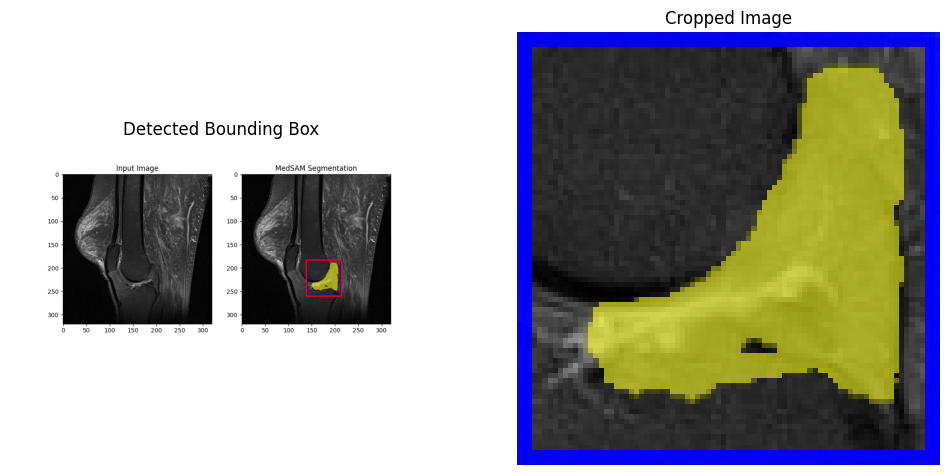

In [ ]:
# Find contours in the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Assuming the largest contour is the bounding box, get the coordinates
if len(contours) > 0:
    # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

    # Get the bounding box coordinates around the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Draw the bounding box on the original image (optional)
    cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Extract the region within the bounding box
    cropped_image = image[y:y+h, x:x+w]

    # Display the original image with bounding box and the cropped image
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(image_rgb)
    axs[0].set_title("Detected Bounding Box")
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))
    axs[1].set_title("Cropped Image")
    axs[1].axis('off')

    plt.show()

    # Save the cropped image (optional)
    new_image_name=image_path.split('/')[-1]
    output_path = '/content/drive/MyDrive/bowen_research/mridata/vol01_cropped/'
    cv2.imwrite(output_path+new_image_name, cropped_image)
else:
    print("No contours found!")